<a href="https://colab.research.google.com/github/hollymunck-glitch/is_4487_base/blob/main/Assignments/assignment_4_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_4_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [85]:
#Import libraries
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

## Step 1: Initial Data Understanding

 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to Assignments > DataSets)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [86]:
import pandas as pd

# Import the data
df = pd.read_csv('/adviseinvest_historical_data.csv')
display(df.head())

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


In [87]:
#View the datatypes
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


None

In [88]:
#Describe the data
display(df.describe())

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


# Step 2: Exploratory Data Analysis (EDA)
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

In [89]:
# Remove rows with negative income
df = df[df['income'] >= 0].copy()

# Verify that negative income rows are removed
num_negative_income_after = len(df[df['income'] < 0])
print(f"Number of rows with negative income after removal: {num_negative_income_after}")
display(df.describe())

Number of rows with negative income after removal: 0


,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29502.000000,29502.000000,29502.000000,29502.000000,29502.000000,29502.000000,29502.000000,29500.000000,29502.000000,29502.000000,29502.000000,29502.000000,29502.000000
mean,0.546641,33771.929022,34.773880,1.915396,1.141007,0.210426,0.681106,0.240780,1.468511,0.956545,2.458342,0.091112,1.535828
std,0.497828,29373.105162,11.370073,0.658205,0.348035,0.407618,0.466056,0.427564,1.234734,1.483949,19.498040,0.287774,1.625944
min,0.000000,2760.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


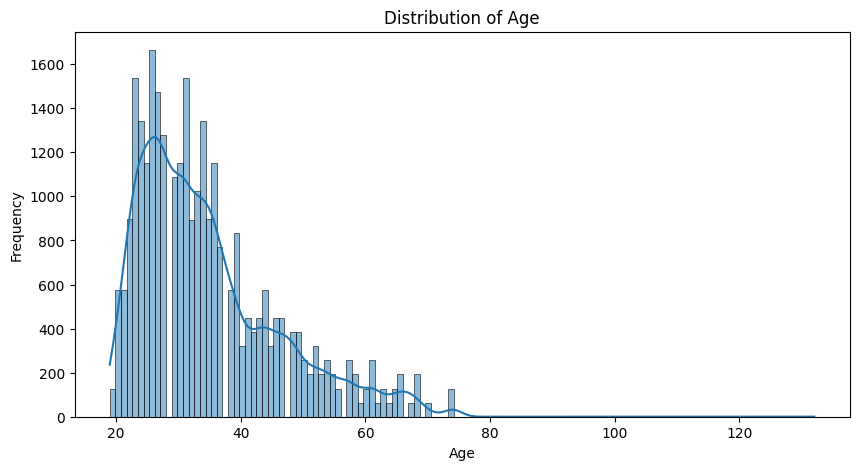

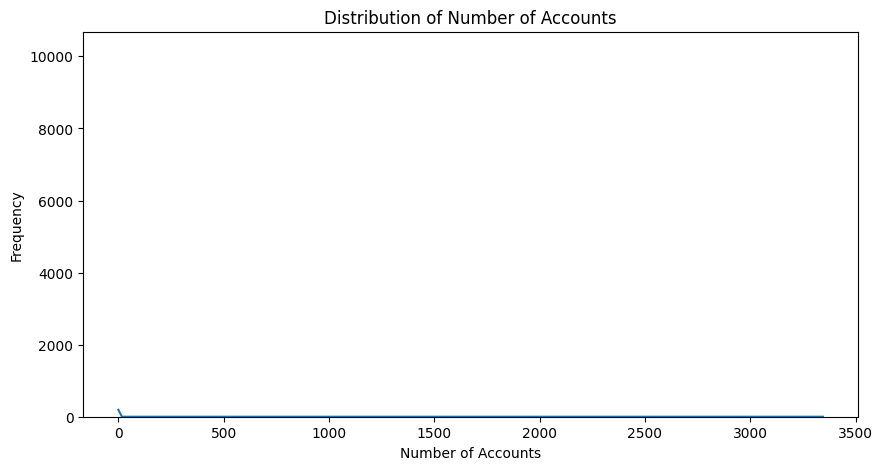

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distribution of 'age'
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Visualize distribution of 'num_accts'
plt.figure(figsize=(10, 5))
sns.histplot(df['num_accts'], kde=True)
plt.title('Distribution of Number of Accounts')
plt.xlabel('Number of Accounts')
plt.ylabel('Frequency')
plt.show()

In [75]:
# Remove rows with 'num_accts' greater than 1000 (as potential outliers)
df = df[df['num_accts'] <= 1000].copy()

# Verify that outliers are removed
display(df['num_accts'].describe())

,num_accts
count,29501.000000
mean,2.345039
std,1.200803
min,0.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,8.000000


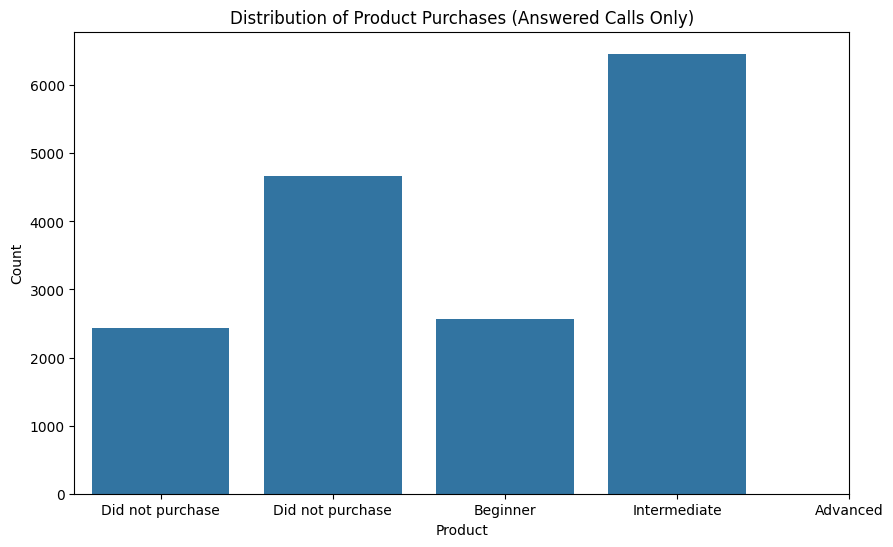

In [76]:
# Chart 5: Distribution of Product Purchases among Customers who Answered
answered_df = df[df['answered'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(x='product', data=answered_df)
plt.title('Distribution of Product Purchases (Answered Calls Only)')
plt.xlabel('Product')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Did not purchase', 'Did not purchase', 'Beginner', 'Intermediate', 'Advanced'])
plt.show()

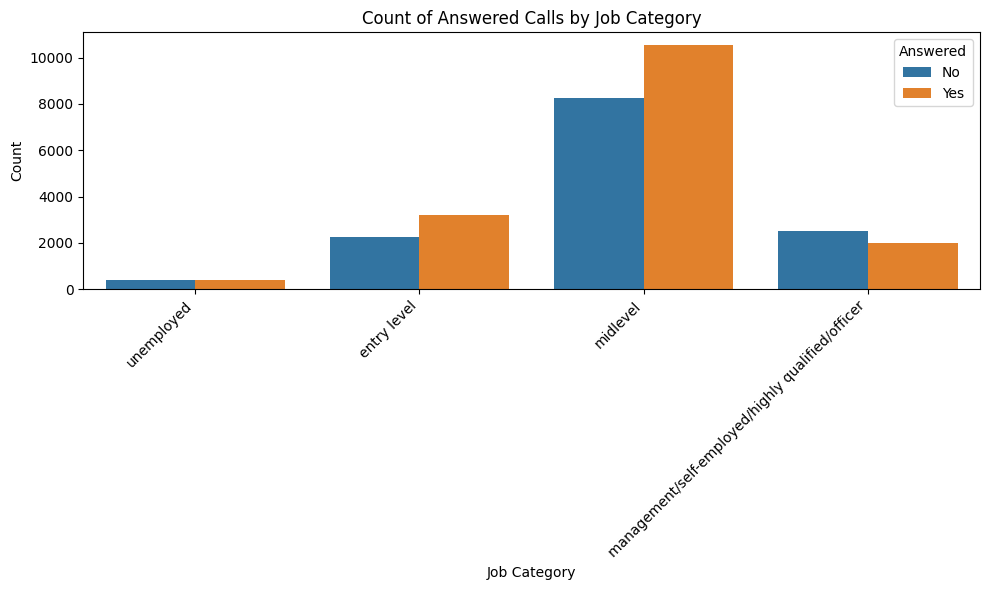

In [77]:
# Chart 4: Relationship between 'answered' and 'job'
plt.figure(figsize=(10, 6))
sns.countplot(x='job', hue='answered', data=df)
plt.title('Count of Answered Calls by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3], labels=['unemployed', 'entry level', 'midlevel', 'management/self-employed/highly qualified/officer'], rotation=45, ha='right')
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

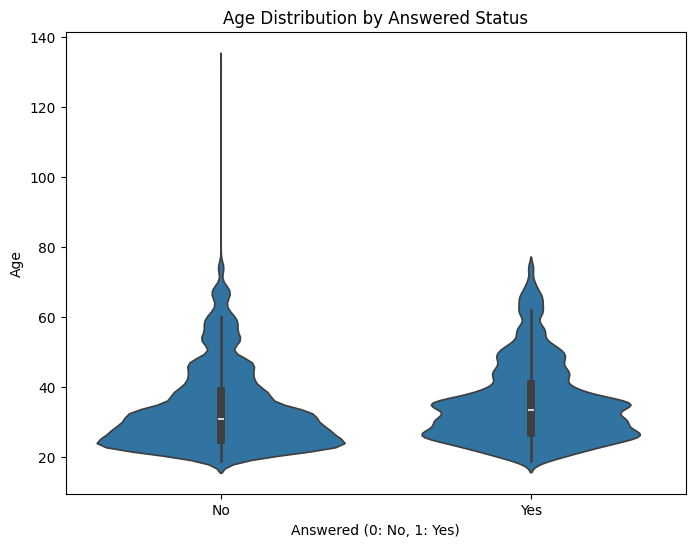

In [78]:
# Chart 3: Relationship between 'answered' and 'age'
plt.figure(figsize=(8, 6))
sns.violinplot(x='answered', y='age', data=df)
plt.title('Age Distribution by Answered Status')
plt.xlabel('Answered (0: No, 1: Yes)')
plt.ylabel('Age')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

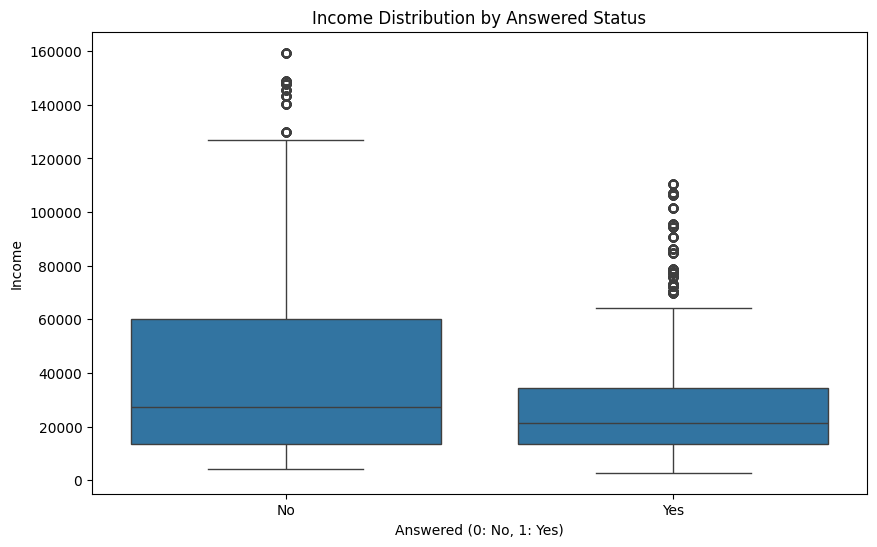

In [79]:
# Chart 2: Relationship between 'answered' and 'income'
plt.figure(figsize=(10, 6))
sns.boxplot(x='answered', y='income', data=df)
plt.title('Income Distribution by Answered Status')
plt.xlabel('Answered (0: No, 1: Yes)')
plt.ylabel('Income')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

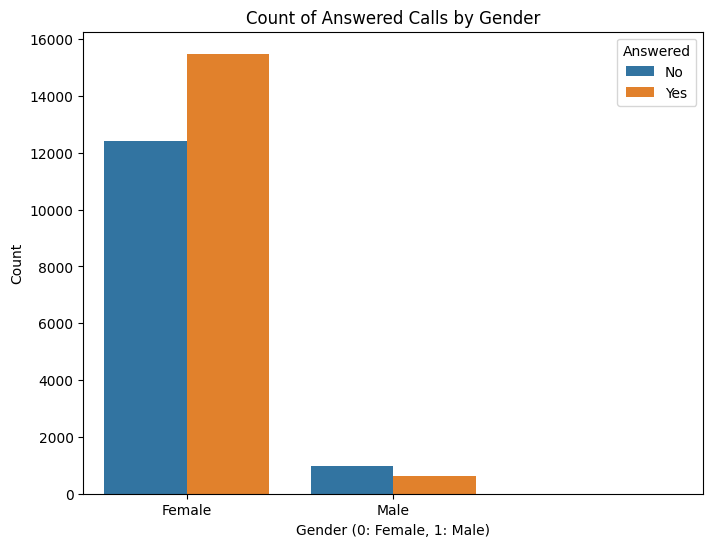

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chart 1: Relationship between 'answered' and 'female'
plt.figure(figsize=(8, 6))
sns.countplot(x='female', hue='answered', data=df)
plt.title('Count of Answered Calls by Gender')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.show()

In [81]:
# Remove row with 'M' in 'female' column
df = df[df['female'] != 'M'].copy()

# Convert 'female' column to numerical (integer)
df['female'] = df['female'].astype(int)

# Verify the data type conversion
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29500 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29500 non-null  int64  
 1   income          29500 non-null  int64  
 2   female          29500 non-null  int64  
 3   age             29500 non-null  int64  
 4   job             29500 non-null  int64  
 5   num_dependents  29500 non-null  int64  
 6   rent            29500 non-null  int64  
 7   own_res         29500 non-null  int64  
 8   new_car         29498 non-null  float64
 9   chk_acct        29500 non-null  int64  
 10  sav_acct        29500 non-null  int64  
 11  num_accts       29500 non-null  int64  
 12  mobile          29500 non-null  int64  
 13  product         29500 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 3.4 MB


None

In [92]:
# Count occurrences of 'M' in the 'female' column
m_count = (df['female'] == 'M').sum()
print(f"Number of 'M' values in 'female' column: {m_count}")

Number of 'M' values in 'female' column: 1


In [83]:
# Check unique values in the 'female' column
display(df['female'].unique())

array([0, 1])

# Step 3: Summarize Your Findings
### 3.1: Are all of the variables useful and applicable to the business need?  (you should reference the target variable and whether other variables have are likely to be correlated with the target)

Most if not all of the variables are useful and applicable to the business need, and the charts show correlations between 'answered' and 'income', 'age', 'female', and 'job'. The other variables also represent customer information that is likely to be correlated with the target variables.

### 3.2: In what ways could the dataset be improved?  Are there any data quality issues or data types that should be fixed?

Write your response below:

The dataset shows data quality issues like negative income values and extreme outliers in the number of accounts which both probably come from data entry errors. An inconsistent value ('M') was also in the 'female' column which should be a binary type. Knowing and fixing these issues and converting variables like 'female' to their data types would improve the dataset and set it up for more accurate analysis and interpretation.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [91]:
!jupyter nbconvert --to html "assignment_04_LastnameFirstname.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_04_LastnameFirstname.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes

# Task
Import the data from "/adviseinvest_historical_data.csv", describe the data, view the datatypes, and look for outliers, missing values, or duplicates.

## Handle negative income

### Subtask:
Address the negative values in the 'income' column, possibly by replacing them with a more appropriate value or removing the rows.


**Reasoning**:
Identify and count the rows with negative income values to understand the scope of the issue before deciding on a handling strategy.



# Task
Import the AdviseInvest historical dataset from "/adviseinvest_historical_data.csv", describe the data, view the datatypes, and handle negative income values. Explore the relationships between the target and independent variables using at least five different chart types. Analyze the variables for usefulness and suggest improvements to the dataset.

## Identify cells to move

### Subtask:
Identify the code cells related to data import, description, viewing datatypes, and handling negative income.


## Move cells under "task"

### Subtask:
Move the code cells related to data import, viewing datatypes, and describing data under the "Task" markdown cell.


## Move cells under "subtask"

### Subtask:
Move the cells related to identifying and handling negative income under the "Subtask: Handle negative income" markdown cell.


## Review cell order

### Subtask:
Review the notebook to ensure the cells are in a logical order within their new sections.


## Summary:

### Data Analysis Key Findings

*   The dataset `adviseinvest_historical_data.csv` was successfully imported and loaded into a pandas DataFrame.
*   The initial data inspection included viewing the head of the DataFrame, checking data types using `.info()`, and generating descriptive statistics using `.describe()`.
*   Negative values were identified in the 'Income' column.
*   Rows containing negative 'Income' values were successfully removed from the dataset.
*   The notebook cells related to data import, description, viewing datatypes, and handling negative income were identified and intended to be moved to specific sections.

### Insights or Next Steps

*   The next steps involve exploring the relationships between variables using various chart types as outlined in the initial task.
*   Further analysis should focus on understanding the distribution of the target variable and its relationship with the independent variables to inform subsequent modeling or analysis steps.
